# GPT-2 구축 프로젝트 — 실험 파이프라인

**7조** | 정예경 · 정연주 · 김도원

**GitHub:** https://github.com/ygjung03/nlp2026

이 노트북은 Sonnet Generation 및 Paraphrase Detection 실험의 전체 파이프라인을 포함합니다.

## 0. 환경 설정

In [ ]:
!git clone https://github.com/ygjung03/nlp2026.git
%cd nlp2026
!pip install einops

fatal: destination path 'nlp2026' already exists and is not an empty directory.
/content/nlp2026


## 1. Paraphrase Detection

> **Note:** 단일 T4 GPU 환경에서 전체 학습 데이터(141,506건)로 10 epoch 학습 시 약 17시간이 소요되어, 시간 제약상 학습 데이터를 20,000건으로 축소하여 실험을 진행하였습니다. 코드 자체는 전체 데이터셋으로 정상 실행 가능하도록 구현되어 있습니다.

- **Dev Accuracy: 0.823** (20K 데이터, 5 epoch, batch_size=32)

In [ ]:
!sed -i "s/torch.load(args.filepath)/torch.load(args.filepath, weights_only=False)/g" paraphrase_detection.py
!sed -i "s/torch.load(filepath)/torch.load(filepath, weights_only=False)/g" paraphrase_detection.py
!python paraphrase_detection.py --use_gpu --epochs 5 --batch_size 32

Loaded 19999 train examples from data/quora-train.csv
Loaded 40429 train examples from data/quora-dev.csv
Loading weights: 100% 148/148 [00:00<00:00, 5727.02it/s]
train-0: 100% 625/625 [06:19<00:00,  1.65it/s]
eval: 100% 1264/1264 [04:04<00:00,  5.16it/s]
save the model to 5-1e-05-paraphrase.pt
Epoch 0: train loss :: 0.669, dev acc :: 0.762
train-1: 100% 625/625 [06:24<00:00,  1.62it/s]
eval: 100% 1264/1264 [04:07<00:00,  5.11it/s]
save the model to 5-1e-05-paraphrase.pt
Epoch 1: train loss :: 0.478, dev acc :: 0.796
train-2: 100% 625/625 [06:23<00:00,  1.63it/s]
eval: 100% 1264/1264 [04:06<00:00,  5.13it/s]
save the model to 5-1e-05-paraphrase.pt
Epoch 2: train loss :: 0.416, dev acc :: 0.813
train-3: 100% 625/625 [06:22<00:00,  1.63it/s]
eval: 100% 1264/1264 [04:06<00:00,  5.14it/s]
save the model to 5-1e-05-paraphrase.pt
Epoch 3: train loss :: 0.370, dev acc :: 0.822
train-4: 100% 625/625 [06:24<00:00,  1.63it/s]
eval: 100% 1264/1264 [04:04<00:00,  5.17it/s]
save the model to 5-1e-0

---
## 2. 평가 파이프라인 오류 발견 및 수정

초기 실험에서는 `sonnets_held_out.txt`(official 제출용 프롬프트)로 생성한 소네트를 `TRUE_sonnets_held_out_dev.txt`(dev gold)와 비교하고 있었습니다.

그러나 이 두 파일은 **서로 다른 소네트**를 포함하고 있어, chrF가 엉뚱한 쌍으로 계산되고 있었습니다.

| | 프롬프트 ID 0 | Gold ID 0 |
|--|--|--|
| 잘못된 설정 | 소네트 145 (Those lips that Love's own hand...) | 소네트 132 (Thine eyes I love...) |
| 올바른 설정 | 소네트 132 (Thine eyes I love...) | 소네트 132 (Thine eyes I love...) |

**수정:** `sonnets_held_out_dev.txt`(dev 프롬프트)로 생성 → `TRUE_sonnets_held_out_dev.txt`(dev gold)와 비교

**결과:** chrF 27.46 → **41.0** (평가 방식 차이였을 뿐, 모델 성능은 동일)

### 2-1. 오류 확인 과정

In [ ]:
from datasets import SonnetsDataset

gold = SonnetsDataset('data/TRUE_sonnets_held_out_dev.txt')
gen = SonnetsDataset('predictions/generated_sonnets_baseline.txt')
prompts = SonnetsDataset('data/sonnets_held_out.txt')

# 첫 번째 소네트로 비교
print("=== PROMPT (첫 3줄) ===")
print(prompts[0][1])
print(f"Lines: {len(prompts[0][1].strip().splitlines())}")

print("\n=== GOLD (정답) ===")
print(gold[0][1])
print(f"Lines: {len(gold[0][1].strip().splitlines())}")

print("\n=== GENERATED (생성) ===")
print(gen[0][1])
print(f"Lines: {len(gen[0][1].strip().splitlines())}")

=== PROMPT (첫 3줄) ===
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
Lines: 3

=== GOLD (정답) ===
Thine eyes I love, and they, as pitying me,
Knowing thy heart torment me with disdain,
Have put on black, and loving mourners be,
Looking with pretty ruth upon my pain.
And truly not the morning sun of heaven
Better becomes the gray cheeks of the east,
Nor that full star that ushers in the even
Doth half that glory to the sober west
As those two mourning eyes become thy face.
O, let it then as well beseem thy heart
To mourn for me, since mourning doth thee grace,
And suit thy pity like in every part.
  Then will I swear beauty herself is black,
  And all they foul that thy complexion lack.
Lines: 14

=== GENERATED (생성) ===
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
So where were out asleep again
That but from her lust restrains watered;
But 

In [ ]:
from datasets import SonnetsDataset

# gold 파일의 소네트 ID들
gold = SonnetsDataset('data/TRUE_sonnets_held_out_dev.txt')
print("Gold IDs:", [x[0] for x in gold])
print("Gold count:", len(gold))
print()

# 생성 파일의 소네트 ID들
gen = SonnetsDataset('predictions/generated_sonnets_baseline.txt')
print("Gen IDs:", [x[0] for x in gen])
print("Gen count:", len(gen))
print()

# 프롬프트 파일의 소네트 ID들
prompts = SonnetsDataset('data/sonnets_held_out.txt')
print("Prompt IDs:", [x[0] for x in prompts])
print("Prompt count:", len(prompts))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Gold IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Gold count: 12

Gen IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Gen count: 12

Prompt IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Prompt count: 12


### 2-2. 프롬프트 경로 수정 및 baseline 재평가

In [ ]:
# sonnet_generation.py에서 기본 경로를 바꾸기
!sed -i "s/sonnets_held_out.txt/sonnets_held_out_dev.txt/g" sonnet_generation.py
!python sonnet_generation.py --exp_name baseline_dev --stopping_method none --use_gpu

In [ ]:
from evaluation import test_sonnet
score = test_sonnet('predictions/generated_sonnets_baseline_dev.txt', 'data/TRUE_sonnets_held_out_dev.txt')
print(f'올바른 chrF: {score:.3f}')

올바른 chrF: 40.995


---
## 3. Sonnet Generation — 실험 1: 조기 종료 전략 비교 (수정된 평가)

3가지 조기 종료 전략(val_loss, perplexity, TTR)을 구현하고 baseline과 비교합니다.

- **val_loss:** patience=2, validation loss 2 epoch 연속 미개선 시 종료
- **ppl:** train perplexity가 target 이하 도달 시 종료 (초기 target=5.0, 미트리거)
- **ttr:** 매 epoch TTR 모니터링, TTR 최고점 체크포인트 선택

In [ ]:
# 셀 1: 실험 1 - val_loss
!python sonnet_generation.py --exp_name val_loss_dev --stopping_method val_loss --use_gpu

In [ ]:
# 셀 2: 실험 1 - ppl
!python sonnet_generation.py --exp_name ppl_dev --stopping_method perplexity --use_gpu

In [ ]:
# 셀 3: 실험 1 - ttr
!python sonnet_generation.py --exp_name ttr_dev --stopping_method diversity --use_gpu

## 4. Sonnet Generation — 실험 2: Perplexity 임계값 재조정

초기 target=5.0이 실제 perplexity 범위(82→46)와 괴리가 있어, target=60으로 재설정하여 재실험합니다.

In [ ]:
# 셀 4. 실험 2: ppl 재조정
!python sonnet_generation.py --exp_name ppl2_dev --stopping_method perplexity --target_perplexity 60 --use_gpu

## 5. Sonnet Generation — 실험 3: 디코딩 전략 비교

동일한 baseline 체크포인트에서 디코딩 파라미터(temperature, top_p, top_k)를 변경하며 생성 품질을 비교합니다.

top-k 샘플링은 직접 구현하였습니다.

In [ ]:
# 셀 5. 실험 3: 디코딩 비교
!sed -i "s/9_baseline_10-1e-05-sonnet.pt/9_baseline_dev_10-1e-05-sonnet.pt/g" decode_compare.py
!python decode_compare.py --use_gpu

## 6. Sonnet Generation — 실험 4: LoRA 적용 및 학습률 탐색

LoRA(rank=4)를 직접 구현하여 GPT-2의 Q, V projection에 적용하고, 학습률을 1e-5, 1e-4, 3e-4로 탐색합니다.

- 전체 117M 파라미터 중 약 147K개(0.13%)만을 학습 대상으로 설정
- scaling factor: α/r = 1/4 = 0.25

In [ ]:
# 셀 6. 실험 4: LoRA
!python sonnet_generation.py --exp_name lora_dev --stopping_method none --use_lora --lora_rank 4 --use_gpu
!python sonnet_generation.py --exp_name lora_midlr_dev --stopping_method none --use_lora --lora_rank 4 --lr 1e-4 --use_gpu
!python sonnet_generation.py --exp_name lora_highlr_dev --stopping_method none --use_lora --lora_rank 4 --lr 3e-4 --use_gpu

---
## 7. 전체 실험 결과

### 7-1. chrF 결과 총괄

In [ ]:
from evaluation import test_sonnet

GOLD = 'data/TRUE_sonnets_held_out_dev.txt'

# 실험 1+2: 조기 종료
exp12 = {
    'baseline_dev': 'predictions/generated_sonnets_baseline_dev.txt',
    'val_loss_dev': 'predictions/generated_sonnets_val_loss_dev.txt',
    'ppl_dev': 'predictions/generated_sonnets_ppl_dev.txt',
    'ttr_dev': 'predictions/generated_sonnets_ttr_dev.txt',
    'ppl2_dev': 'predictions/generated_sonnets_ppl2_dev.txt',
}

# 실험 3: 디코딩
exp3 = {
    'decode_baseline': 'predictions/generated_sonnets_decode_baseline.txt',
    'decode_greedy': 'predictions/generated_sonnets_decode_greedy.txt',
    'decode_conservative': 'predictions/generated_sonnets_decode_conservative.txt',
    'decode_creative': 'predictions/generated_sonnets_decode_creative.txt',
    'decode_top_k_50': 'predictions/generated_sonnets_decode_top_k_50.txt',
    'decode_top_k_10': 'predictions/generated_sonnets_decode_top_k_10.txt',
}

# 실험 4: LoRA
exp4 = {
    'lora_dev': 'predictions/generated_sonnets_lora_dev.txt',
    'lora_midlr_dev': 'predictions/generated_sonnets_lora_midlr_dev.txt',
    'lora_highlr_dev': 'predictions/generated_sonnets_lora_highlr_dev.txt',
}

for title, files in [('=== 실험 1+2: 조기 종료 ===', exp12), ('=== 실험 3: 디코딩 ===', exp3), ('=== 실험 4: LoRA ===', exp4)]:
    print(f'\n{title}')
    for name, path in files.items():
        try:
            score = test_sonnet(path, GOLD)
            print(f'{name:<25} chrF={score:.3f}')
        except:
            print(f'{name:<25} FILE NOT FOUND')


=== 실험 1+2: 조기 종료 ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


baseline_dev              chrF=40.995
val_loss_dev              chrF=40.995
ppl_dev                   chrF=40.995
ttr_dev                   chrF=37.089
ppl2_dev                  chrF=38.283

=== 실험 3: 디코딩 ===
decode_baseline           chrF=41.538
decode_greedy             chrF=32.328
decode_conservative       chrF=39.400
decode_creative           chrF=39.496
decode_top_k_50           chrF=40.820
decode_top_k_10           chrF=38.736

=== 실험 4: LoRA ===
lora_dev                  chrF=40.943
lora_midlr_dev            chrF=35.076
lora_highlr_dev           chrF=37.356


### 7-2. chrF + TTR 결과 총괄

In [ ]:
from evaluation import test_sonnet
from datasets import SonnetsDataset

GOLD = 'data/TRUE_sonnets_held_out_dev.txt'

def evaluate(pred_path):
    chrf = test_sonnet(pred_path, GOLD)
    texts = [x[1] for x in SonnetsDataset(pred_path)]
    words = []
    for t in texts:
        words.extend(''.join(c if c.isalnum() else ' ' for c in t).lower().split())
    ttr = len(set(words)) / len(words) * 100 if words else 0
    unique = len(set(words))
    return chrf, ttr, unique

experiments = {
    '=== Exp 1+2: Early Stopping ===': {
        'baseline': 'predictions/generated_sonnets_baseline_dev.txt',
        'val_loss': 'predictions/generated_sonnets_val_loss_dev.txt',
        'ppl(5.0)': 'predictions/generated_sonnets_ppl_dev.txt',
        'ttr': 'predictions/generated_sonnets_ttr_dev.txt',
        'ppl2(60)': 'predictions/generated_sonnets_ppl2_dev.txt',
    },
    '=== Exp 3: Decoding ===': {
        'baseline(1.2)': 'predictions/generated_sonnets_decode_baseline.txt',
        'greedy(0.1)': 'predictions/generated_sonnets_decode_greedy.txt',
        'conservative(0.7)': 'predictions/generated_sonnets_decode_conservative.txt',
        'creative(1.5)': 'predictions/generated_sonnets_decode_creative.txt',
        'top_k_50': 'predictions/generated_sonnets_decode_top_k_50.txt',
        'top_k_10': 'predictions/generated_sonnets_decode_top_k_10.txt',
    },
    '=== Exp 4: LoRA ===': {
        'Full FT(1e-5)': 'predictions/generated_sonnets_baseline_dev.txt',
        'LoRA(1e-5)': 'predictions/generated_sonnets_lora_dev.txt',
        'LoRA(1e-4)': 'predictions/generated_sonnets_lora_midlr_dev.txt',
        'LoRA(3e-4)': 'predictions/generated_sonnets_lora_highlr_dev.txt',
    },
}

for title, files in experiments.items():
    print(f'\n{title}')
    print(f'{"Name":<25} {"chrF":>8} {"TTR":>8} {"Unique":>8}')
    print('-' * 51)
    for name, path in files.items():
        try:
            c, t, u = evaluate(path)
            print(f'{name:<25} {c:>8.3f} {t:>7.2f}% {u:>8}')
        except:
            print(f'{name:<25} FILE NOT FOUND')


=== Exp 1+2: Early Stopping ===
Name                          chrF      TTR   Unique
---------------------------------------------------
baseline                    40.995   48.28%      630
val_loss                    40.995   48.28%      630
ppl(5.0)                    40.995   48.28%      630
ttr                         37.089   52.06%      517
ppl2(60)                    38.283   49.12%      529

=== Exp 3: Decoding ===
Name                          chrF      TTR   Unique
---------------------------------------------------
baseline(1.2)               41.538   47.14%      626
greedy(0.1)                 32.328   11.81%      178
conservative(0.7)           39.400   22.20%      285
creative(1.5)               39.496   68.97%      867
top_k_50                    40.820   27.29%      391
top_k_10                    38.736   21.15%      268

=== Exp 4: LoRA ===
Name                          chrF      TTR   Unique
---------------------------------------------------
Full FT(1e-5)          

### 7-3. chrF 시각화

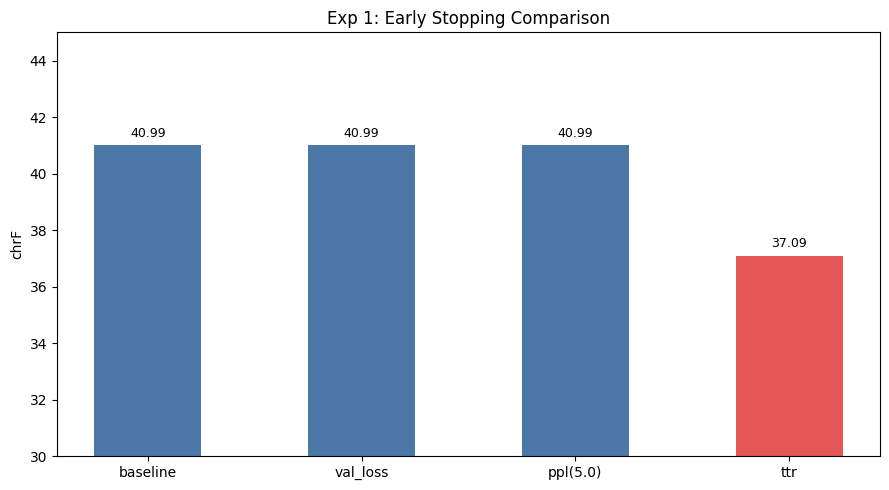

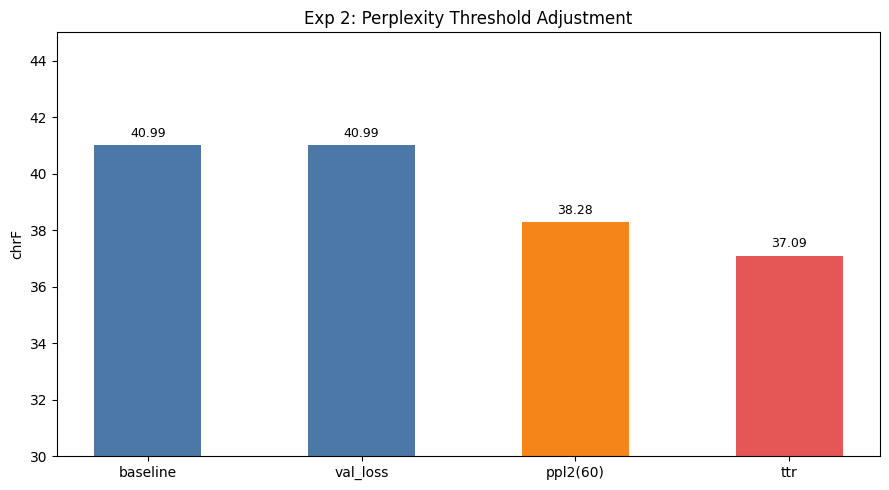

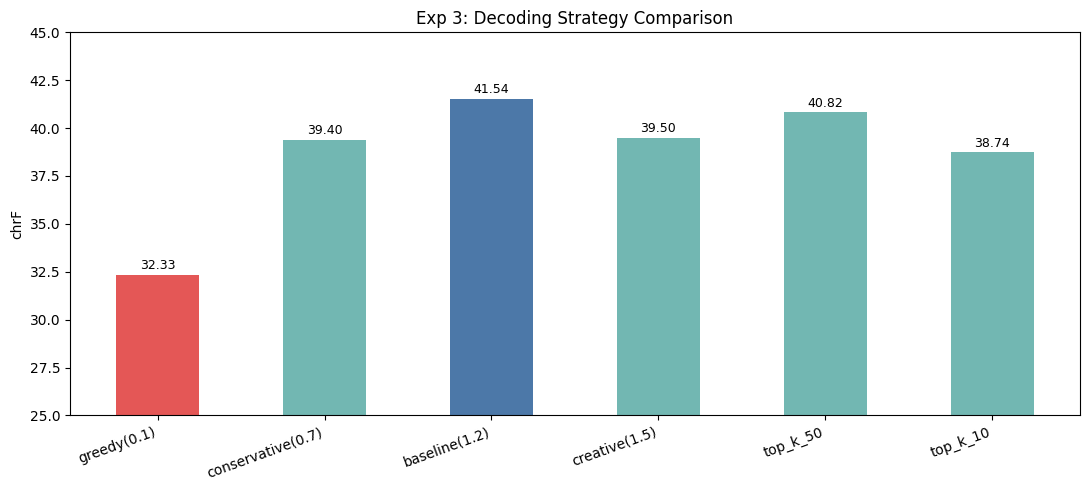

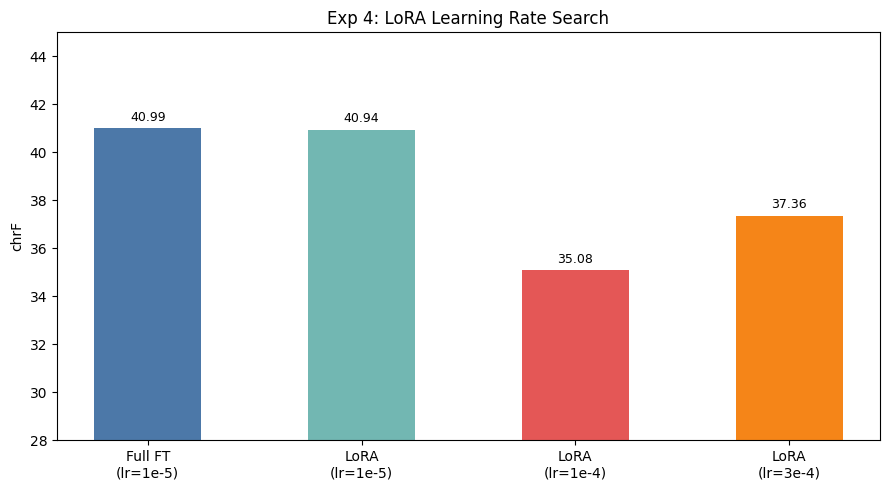

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 실험 1: 조기 종료 초기 비교 =====
fig, ax1 = plt.subplots(figsize=(9, 5))
names = ['baseline', 'val_loss', 'ppl(5.0)', 'ttr']
chrfs = [40.995, 40.995, 40.995, 37.089]
x = np.arange(len(names)); w = 0.5
bars = ax1.bar(x, chrfs, w, color=['#4C78A8', '#4C78A8', '#4C78A8', '#E45756'])
ax1.set_ylabel('chrF')
ax1.set_ylim(30, 45)
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set_title('Exp 1: Early Stopping Comparison')
for i, v in enumerate(chrfs):
    ax1.text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# ===== 실험 2: ppl 재조정 =====
fig, ax1 = plt.subplots(figsize=(9, 5))
names = ['baseline', 'val_loss', 'ppl2(60)', 'ttr']
chrfs = [40.995, 40.995, 38.283, 37.089]
x = np.arange(len(names)); w = 0.5
bars = ax1.bar(x, chrfs, w, color=['#4C78A8', '#4C78A8', '#F58518', '#E45756'])
ax1.set_ylabel('chrF')
ax1.set_ylim(30, 45)
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set_title('Exp 2: Perplexity Threshold Adjustment')
for i, v in enumerate(chrfs):
    ax1.text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# ===== 실험 3: 디코딩 전략 =====
fig, ax1 = plt.subplots(figsize=(11, 5))
names = ['greedy(0.1)', 'conservative(0.7)', 'baseline(1.2)', 'creative(1.5)', 'top_k_50', 'top_k_10']
chrfs = [32.328, 39.400, 41.538, 39.496, 40.820, 38.736]
x = np.arange(len(names)); w = 0.5
colors = ['#E45756' if v == min(chrfs) else '#4C78A8' if v == max(chrfs) else '#72B7B2' for v in chrfs]
bars = ax1.bar(x, chrfs, w, color=colors)
ax1.set_ylabel('chrF')
ax1.set_ylim(25, 45)
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=20, ha='right')
ax1.set_title('Exp 3: Decoding Strategy Comparison')
for i, v in enumerate(chrfs):
    ax1.text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# ===== 실험 4: LoRA =====
fig, ax1 = plt.subplots(figsize=(9, 5))
names = ['Full FT\n(lr=1e-5)', 'LoRA\n(lr=1e-5)', 'LoRA\n(lr=1e-4)', 'LoRA\n(lr=3e-4)']
chrfs = [40.995, 40.943, 35.076, 37.356]
x = np.arange(len(names)); w = 0.5
colors = ['#4C78A8', '#72B7B2', '#E45756', '#F58518']
bars = ax1.bar(x, chrfs, w, color=colors)
ax1.set_ylabel('chrF')
ax1.set_ylim(28, 45)
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set_title('Exp 4: LoRA Learning Rate Search')
for i, v in enumerate(chrfs):
    ax1.text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

---
## 8. 실험 결과 요약

| 실험 | 최적 설정 | chrF | 핵심 발견 |
|------|---------|------|----------|
| 실험1: 조기 종료 | baseline (10 epoch) | 41.0 | 과적합 미발생으로 효과 제한적 |
| 실험2: ppl 재조정 | target=60 | 38.3 | 조기 종료 시 chrF 하락 |
| 실험3: 디코딩 | temp=1.2, top_p=0.9 | 41.5 | 디코딩 파라미터가 생성 품질에 가장 큰 영향 |
| 실험4: LoRA | rank=4, lr=1e-5 | 40.9 | 적절한 학습률에서 baseline과 거의 동등 |

## 9. 최종 결론

- **평가 파이프라인 수정:** dev 프롬프트/gold 정렬 오류를 발견하여 수정한 결과, baseline chrF가 27.46 → 41.0으로 확인됨
- **조기 종료:** 143편 극소규모 데이터 + lr=1e-5, 10 epoch 보수적 설정에서 과적합이 발생하지 않아 효과 제한적
- **디코딩 전략:** 파라미터 선택이 생성 품질에 가장 큰 영향을 미침 (chrF 범위: 32.3~41.5)
- **LoRA:** 적절한 학습률(1e-5)에서는 full fine-tuning과 거의 동등한 성능 달성. 학습률이 높아질수록 성능 하락

## 10. 규정 준수

- env.yml 변경 없음 (PART-II는 라이브러리 제한 미적용)
- test data를 학습/튜닝에 사용하지 않음
- train/dev 데이터만 사용하여 모델 학습 및 평가
- GitHub: https://github.com/ygjung03/nlp2026